# Safety Sub-Metric: Pittsburgh Police Arrests (2024–2026)

**Dataset:** [Pittsburgh Police Arrests (2024–2026)](https://data.wprdc.org/dataset/pbp_arrest_data_2024_2025) — City of Pittsburgh / WPRDC

## Introduction

My sub-metric for this project is **safety**. The idea is simple: a neighborhood where fewer people get arrested is, on average, a safer place to live. Feeling safe in your own neighborhood is a basic quality-of-life need, so I'm using arrest counts per neighborhood as a proxy for safety.

The dataset I'm using is the **Pittsburgh Police Arrests (2024–2026)** from the Western Pennsylvania Regional Data Center (WPRDC). It contains every police arrest logged by the Pittsburgh Bureau of Police from January 2024 through early 2026, following the NIBRS (National Incident-Based Reporting System) standard.

**My approach:**
1. Load and explore the arrest data
2. Count total arrests per neighborhood
3. Normalize into a 0–1 safety score (higher = safer = fewer arrests)
4. Visualize the results
5. Report the safest (and least safe) neighborhoods

## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

print("Libraries have been imported successfully.")

Libraries have been imported successfully.


## Step 2: Load the Data

Download the `.xlsx` file from the WPRDC link below and place it in the same folder as this notebook:

> **Download link:** https://data.wprdc.org/dataset/b62e8c3f-f40e-4b3f-9c60-82509bc397fb/resource/e419c20c-8df4-4729-830c-e49427a656e0/download/arrests_2024_thru_mar2026.xlsx

Save it as `arrests_2024_thru_mar2026.xlsx` in your repo folder.

In [3]:
!pip install openpyxl --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [4]:
# Load the Excel file
df = pd.read_excel('arrests_2024_thru_mar2026.xlsx')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns:')
print(df.columns.tolist())

Dataset shape: (43435, 25)

Columns:
['Template', 'Case_Number', 'ArrestPerson_ID', 'Arrest_Date', 'Arrest_Year', 'Arrest_Month', 'Arrest_Time', 'Type', 'ArrestPerson_Age', 'ArrestPerson_Sex', 'ArrestPerson_Race', 'NIBRS_Coded_Offense', 'NIBRS_Offense_Code', 'NIBRS_Offense_Category', 'NIBRS_Offense_Type', 'NIBRS_Crime_Against', 'NIBRS_Offense_Grouping', 'Violation', 'Zone', 'Tract', 'Neighborhood', 'ArrestCharge_Felony_Misdemeanor_Description', 'XCOORD', 'YCOORD', 'Block_Address']


## Step 3: Explore the data

In [5]:
# Previewing the first few rows
df.head(10)

,Template,Case_Number,ArrestPerson_ID,Arrest_Date,Arrest_Year,Arrest_Month,Arrest_Time,Type,ArrestPerson_Age,ArrestPerson_Sex,...,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,Zone,Tract,Neighborhood,ArrestCharge_Felony_Misdemeanor_Description,XCOORD,YCOORD,Block_Address
0,Adult Arrest-On View,PGHP26028801,a50bb4e9-1417-c449-66ab-08de7753d503,2026-02-28,2026.0,Feb,22:54,On-View Arrest (apprehension without a warrant...,25.0,M,...,Person,A,18 2718 A1 Strangulation Basic - Applying,Zone 4,1504.0,Glen Hazel,MISDEMEANOR - M2,-79.9332,40.4054,"700 BLOCK OF JOHNSTON AVE PITTSBURGH, PA"
1,Adult Arrest-On View,PGHP26028801,a50bb4e9-1417-c449-66ab-08de7753d503,2026-02-28,2026.0,Feb,22:54,On-View Arrest (apprehension without a warrant...,25.0,M,...,Person,A,18 2701 A1 Simple Assault-General,Zone 4,1504.0,Glen Hazel,MISDEMEANOR - M2,-79.9332,40.4054,"700 BLOCK OF JOHNSTON AVE PITTSBURGH, PA"
2,Adult Arrest-302,PGHP26028803,fe3728d9-7382-c593-4319-08de77516c71,2026-02-28,2026.0,Feb,22:32,Taken Into Custody (based on a warrant and/or ...,32.0,M,...,Group B,B,302 302 Warrant,Zone 1,2615.0,Perry South,NaN,-80.0078,40.4718,"2600 BLOCK OF MAPLE AVE, PITTSBURGH 15214 PITT..."
3,Juvenile Arrest - 302,PGHP26028828,a480b72c-43fb-c021-c415-08de77572633,2026-02-28,2026.0,Feb,23:17,Taken Into Custody (based on a warrant and/or ...,13.0,M,...,Group B,B,302 302 Warrant,Zone 3,2902.0,Carrick,NaN,-79.9831,40.4012,"1500 BLOCK OF TRANSVERSE PITTSBURGH, PA"
4,Adult Arrest-On View,PGHP26028804,5dd0ef50-ace6-c129-2bc1-08de7758642a,2026-02-28,2026.0,Feb,22:27,On-View Arrest (apprehension without a warrant...,23.0,M,...,Person,A,18 2706 A1 Terroristic Threats-General,Zone 2,203.0,Strip District,MISDEMEANOR - M1,-79.9723,40.4639,NaN
5,Adult Arrest-Warrant (from PBP),PGHP25087521,9717c796-a31d-c495-96c1-08de7764471b,NaT,NaN,NaN,NaN,Taken Into Custody (based on a warrant and/or ...,24.0,M,...,Person,A,18 2701 A1 Simple Assault-General,Zone 3,2902.0,Carrick,MISDEMEANOR - M2,-79.9862,40.3964,"100 BLOCK OF POPLARGROVE ST PITTSBURGH, PA"
6,Adult Arrest-On View,PGHP26028929,0e5a88d6-fa9b-cf95-0d2f-08de7769c654,2026-03-01,2026.0,Mar,03:08,On-View Arrest (apprehension without a warrant...,54.0,M,...,Person,A,18 2701 A1 Simple Assault-General,Zone 1,2614.0,Perry South,MISDEMEANOR - M2,-80.0140,40.4635,"1900 BLOCK OF PERRYSVILLE AVE PITTSBURGH, PA"
7,Adult Arrest-On View,PGHP26028929,0e5a88d6-fa9b-cf95-0d2f-08de7769c654,2026-03-01,2026.0,Mar,03:08,On-View Arrest (apprehension without a warrant...,54.0,M,...,Person,A,18 2718 A1 Strangulation Enhanced – Applying F...,Zone 1,2614.0,Perry South,FELONY - F2,-80.0140,40.4635,"1900 BLOCK OF PERRYSVILLE AVE PITTSBURGH, PA"
8,Adult Arrest-On View,PGHP26028886,a32285e5-927a-c37e-5e85-08de776a7c79,NaT,NaN,NaN,NaN,On-View Arrest (apprehension without a warrant...,21.0,M,...,Property,A,75 7122 3 Possess/Sell/Use an Altered/Forged/C...,Zone 3,1702.0,South Side Flats,MISDEMEANOR - M1,-79.9806,40.4283,NaN
9,Adult Arrest-On View,PGHP25000026,b09e1066-c355-cc1b-218c-08dd2a4354ea,2025-01-01,2025.0,Jan,04:04,On-View Arrest (apprehension without a warrant...,21.0,Female,...,Group B,B,18 5503 A1* Disorderly Conduct-Fighting/Threat...,Zone 3,1702.0,South Side Flats,MISDEMEANOR - M3,-79.9824,40.4288,"1600 Block of E Carson Street Pittsburgh, PA"


In [6]:
# Checking data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43435 entries, 0 to 43434
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Template                                     43435 non-null  object        
 1   Case_Number                                  43412 non-null  object        
 2   ArrestPerson_ID                              43434 non-null  object        
 3   Arrest_Date                                  42968 non-null  datetime64[ns]
 4   Arrest_Year                                  42968 non-null  float64       
 5   Arrest_Month                                 42968 non-null  object        
 6   Arrest_Time                                  42968 non-null  object        
 7   Type                                         43434 non-null  object        
 8   ArrestPerson_Age                             43425 non-null  float64       


In [7]:
# Look at unique values in the neighborhood column
# (column name may vary — adjust 'NEIGHBORHOOD' below if needed after checking df.columns above)
neighborhood_col = [col for col in df.columns if 'NEIGHBOR' in col.upper() or 'HOOD' in col.upper()]
print('Neighborhood-related columns found:', neighborhood_col)

# Use the first match
if neighborhood_col:
    nbhd_col = neighborhood_col[0]
    print(f'\nUsing column: "{nbhd_col}"')
    print(f'Unique neighborhoods: {df[nbhd_col].nunique()}')
    print(f'\nSample values:')
    print(df[nbhd_col].value_counts().head(10))
else:
    print('No neighborhood column auto-detected — check df.columns and set nbhd_col manually!')

Neighborhood-related columns found: ['Neighborhood']

Using column: "Neighborhood"
Unique neighborhoods: 95

Sample values:
Neighborhood
Central Business District    5781
South Side Flats             3247
East Allegheny               1751
Bluff                        1587
Carrick                      1248
East Liberty                 1150
Knoxville                    1007
Homewood South                912
Homewood North                837
Crawford-Roberts              719
Name: count, dtype: int64


## Step 4: Clean the Data

In [8]:
# Drop rows where neighborhood is missing
df_clean = df.dropna(subset=[nbhd_col]).copy()

# Standardize neighborhood names: strip whitespace, title case
df_clean[nbhd_col] = df_clean[nbhd_col].str.strip().str.title()

print(f'Rows before cleaning: {len(df)}')
print(f'Rows after dropping missing neighborhoods: {len(df_clean)}')

Rows before cleaning: 43435
Rows after dropping missing neighborhoods: 38671


## Step 5: Count Arrests Per Neighborhood

In [9]:
# Count total arrests per neighborhood
arrest_counts = df_clean[nbhd_col].value_counts().reset_index()
arrest_counts.columns = ['neighborhood', 'arrest_count']
arrest_counts = arrest_counts.sort_values('arrest_count', ascending=False).reset_index(drop=True)

print(f'Total neighborhoods: {len(arrest_counts)}')
print(f'\nTop 10 neighborhoods by arrest count (least safe):')
print(arrest_counts.head(10).to_string(index=False))

print(f'\nBottom 10 neighborhoods by arrest count (safest):')
print(arrest_counts.tail(10).to_string(index=False))

Total neighborhoods: 95

Top 10 neighborhoods by arrest count (least safe):
             neighborhood  arrest_count
Central Business District          5781
         South Side Flats          3247
           East Allegheny          1751
                    Bluff          1587
                  Carrick          1248
             East Liberty          1150
                Knoxville          1007
           Homewood South           912
           Homewood North           837
         Crawford-Roberts           719

Bottom 10 neighborhoods by arrest count (safest):
  neighborhood  arrest_count
 East Carnegie            33
 New Homestead            29
 Regent Square            24
     Chartiers            23
Swisshelm Park            17
     Ridgemont            17
   Saint Clair            16
   South Shore            11
     St. Clair             4
Chartiers City             4


## Step 6: Normalize into a Safety Score (0–1)

To combine with my teammates' sub-metrics, I need a normalized score where:
- **1.0 = safest** (fewest arrests)
- **0.0 = least safe** (most arrests)

I'll use min-max normalization and invert it so that fewer arrests = higher score.

In [10]:
# Min-max normalization (inverted: fewer arrests = higher safety score)
min_arrests = arrest_counts['arrest_count'].min()
max_arrests = arrest_counts['arrest_count'].max()

arrest_counts['safety_score'] = 1 - (
    (arrest_counts['arrest_count'] - min_arrests) / (max_arrests - min_arrests)
)

# Round for readability
arrest_counts['safety_score'] = arrest_counts['safety_score'].round(4)

# Sort by safety score descending
arrest_counts = arrest_counts.sort_values('safety_score', ascending=False).reset_index(drop=True)

print('Top 10 SAFEST neighborhoods (by safety score):')
print(arrest_counts.head(10)[['neighborhood', 'arrest_count', 'safety_score']].to_string(index=False))

print('\nBottom 10 LEAST SAFE neighborhoods:')
print(arrest_counts.tail(10)[['neighborhood', 'arrest_count', 'safety_score']].to_string(index=False))

Top 10 SAFEST neighborhoods (by safety score):
  neighborhood  arrest_count  safety_score
Chartiers City             4        1.0000
     St. Clair             4        1.0000
   South Shore            11        0.9988
   Saint Clair            16        0.9979
     Ridgemont            17        0.9977
Swisshelm Park            17        0.9977
     Chartiers            23        0.9967
 Regent Square            24        0.9965
 New Homestead            29        0.9957
 East Carnegie            33        0.9950

Bottom 10 LEAST SAFE neighborhoods:
             neighborhood  arrest_count  safety_score
         Crawford-Roberts           719        0.8762
           Homewood North           837        0.8558
           Homewood South           912        0.8428
                Knoxville          1007        0.8264
             East Liberty          1150        0.8016
                  Carrick          1248        0.7847
                    Bluff          1587        0.7260
           

## Step 7: Visualize the Results


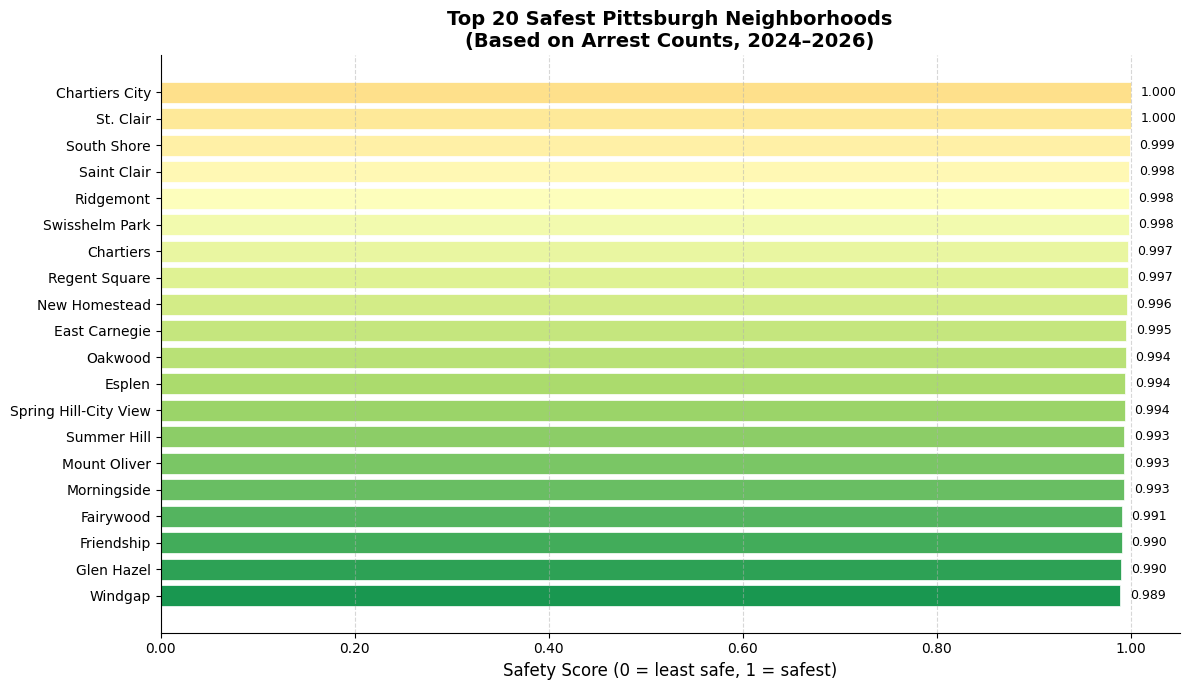

Chart saved as safety_top20_safest.png


In [11]:
# --- Bar chart: Top 20 safest neighborhoods ---
top20 = arrest_counts.head(20).copy()

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(top20)))
bars = ax.barh(top20['neighborhood'][::-1], top20['safety_score'][::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)

ax.set_xlabel('Safety Score (0 = least safe, 1 = safest)', fontsize=12)
ax.set_title('Top 20 Safest Pittsburgh Neighborhoods\n(Based on Arrest Counts, 2024–2026)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for bar, score in zip(bars, top20['safety_score'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('safety_top20_safest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as safety_top20_safest.png')

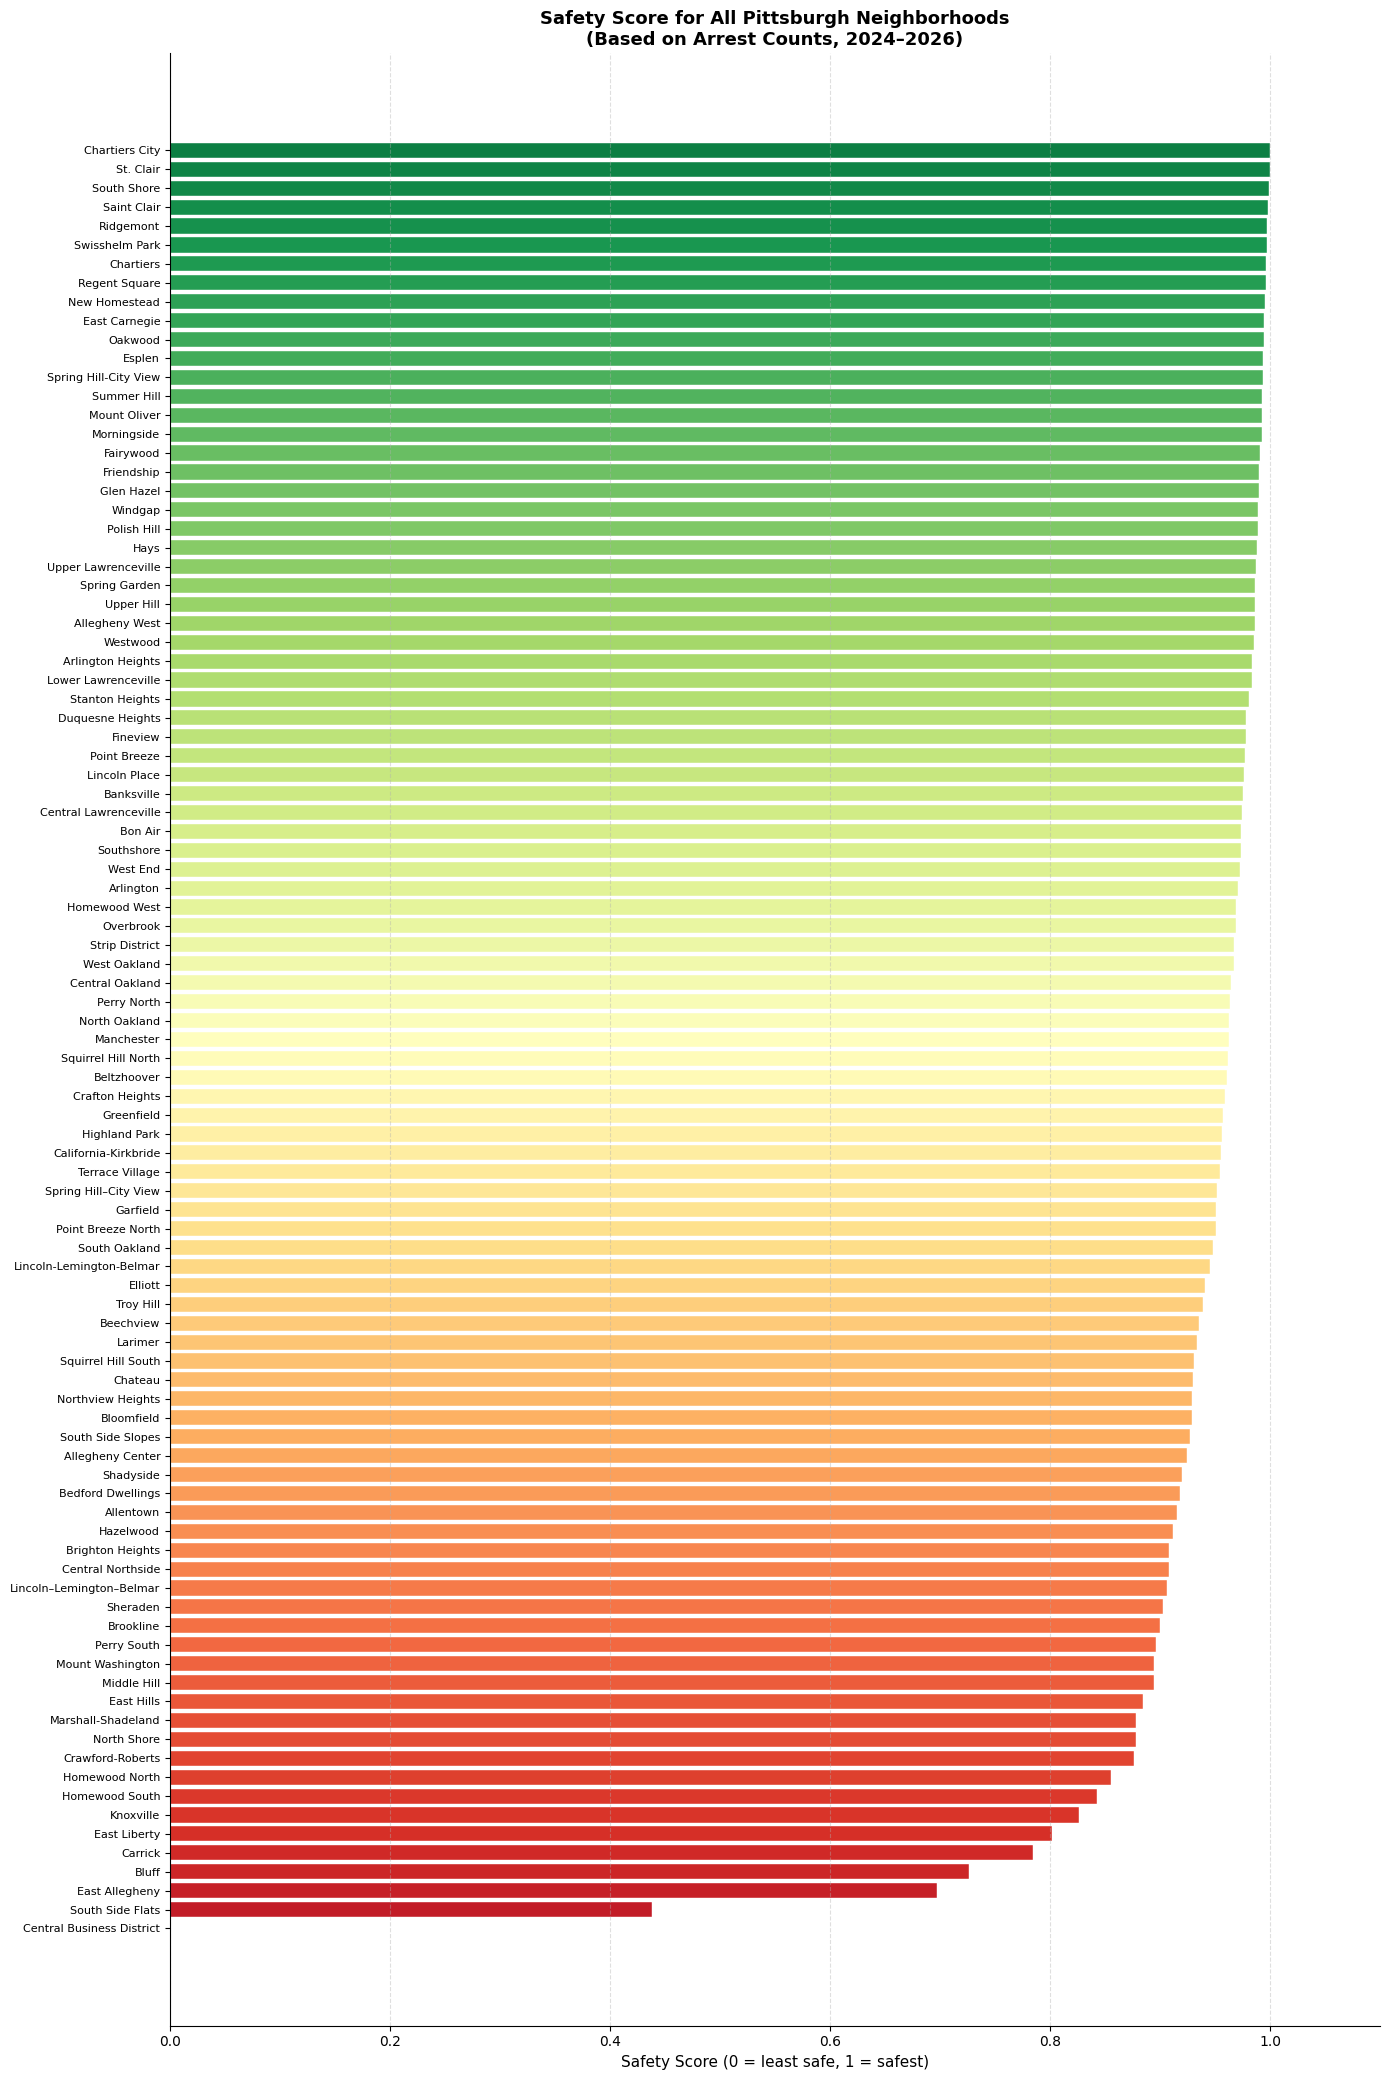

Chart saved as safety_all_neighborhoods.png


In [12]:
# --- Bar chart: All neighborhoods, full ranking ---
fig, ax = plt.subplots(figsize=(14, max(10, len(arrest_counts) * 0.22)))

sorted_all = arrest_counts.sort_values('safety_score')
colors_all = plt.cm.RdYlGn(np.linspace(0.05, 0.95, len(sorted_all)))

ax.barh(sorted_all['neighborhood'], sorted_all['safety_score'], color=colors_all, edgecolor='white', linewidth=0.3)

ax.set_xlabel('Safety Score (0 = least safe, 1 = safest)', fontsize=11)
ax.set_title('Safety Score for All Pittsburgh Neighborhoods\n(Based on Arrest Counts, 2024–2026)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('safety_all_neighborhoods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as safety_all_neighborhoods.png')

## Step 8: The Safest Neighborhood

In [13]:
safest = arrest_counts.iloc[0]
least_safe = arrest_counts.iloc[-1]

print(f"In summary:")
print('=' * 50)
print(f"SAFEST NEIGHBORHOOD: {safest['neighborhood']}")
print(f"   Arrests: {safest['arrest_count']}  |  Safety Score: {safest['safety_score']:.4f}")
print('=' * 50)
print(f"Least safe: {least_safe['neighborhood']}")
print(f"   Arrests: {least_safe['arrest_count']}  |  Safety Score: {least_safe['safety_score']:.4f}")

In summary:
SAFEST NEIGHBORHOOD: Chartiers City
   Arrests: 4  |  Safety Score: 1.0000
Least safe: Central Business District
   Arrests: 5781  |  Safety Score: 0.0000


## Step 9: Export Safety Scores for Combined Notebook

Save the scores to a CSV so the combined group notebook can merge all three sub-metrics.

In [14]:
# Export for use in combined notebook
export_df = arrest_counts[['neighborhood', 'arrest_count', 'safety_score']].copy()
export_df.to_csv('safety_scores.csv', index=False)

print('Exported safety_scores.csv')
print(f'Shape: {export_df.shape}')
export_df.head()

Exported safety_scores.csv
Shape: (95, 3)


,neighborhood,arrest_count,safety_score
0,Chartiers City,4,1.0000
1,St. Clair,4,1.0000
2,South Shore,11,0.9988
3,Saint Clair,16,0.9979
4,Ridgemont,17,0.9977


## Conclusion

Using arrest data from the Pittsburgh Bureau of Police (2024–2026), I calculated a safety score for each Pittsburgh neighborhood. Neighborhoods with fewer arrests received a higher score (closer to 1.0), while neighborhoods with more arrests received a lower score (closer to 0.0).

**Key findings:**
- The safest neighborhood according to this metric is Chartiers City and St.Clair, with a safety score of 1.0.
- The least safe is Central Business District, with 5781 arrests over the time period.
- There is a wide spread in arrest counts across Pittsburgh's neighborhoods, suggesting that safety varies significantly depending on where you live.

**Limitations to consider:**
- Arrest counts don't account for neighborhood population size — a large neighborhood will naturally have more arrests even if it's relatively safe per capita. Ideally, we'd normalize by population.
- Arrests are not the same as crime — they reflect police activity and reporting as much as actual criminal behavior.
- This data only covers 2024–early 2026, so it's a snapshot rather than a long-term trend.

Despite these caveats, arrest counts remain a useful and accessible proxy for safety. This score will be combined equally with my teammates' quality-of-life (parks) and accessibility (transit) scores to produce our group's overall "best neighborhood" ranking.

---
